In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math

data used: https://www.kaggle.com/datasets/adilimadeddinehosni/multi-resistance-antibiotic-susceptibility/data

# **Preprocessing**


*   Checking for missing data
*   Standardizing data
*   Switching ro numerical values



In [ ]:
data = pd.read_csv("Bacteria_dataset_Multiresistance.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10710 entries, 0 to 10709
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 10710 non-null  object
 1   Name               10710 non-null  object
 2   Email              10710 non-null  object
 3   Address            10710 non-null  object
 4   age/gender         10089 non-null  object
 5   Souches            10070 non-null  object
 6   Diabetes           10075 non-null  object
 7   Hypertension       10080 non-null  object
 8   Hospital_before    10073 non-null  object
 9   Infection_Freq     10071 non-null  object
 10  AMX/AMP            10052 non-null  object
 11  AMC                10078 non-null  object
 12  CZ                 10082 non-null  object
 13  FOX                10085 non-null  object
 14  CTX/CRO            10086 non-null  object
 15  IPM                10077 non-null  object
 16  GEN                10067 non-null  objec

In [ ]:
data.head()

,ID,Name,Email,Address,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,...,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,Collection_Date,Notes
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",37/F,S290 Escherichia coli,No,No,No,0.0,...,S,S,S,S,R,S,S,S,5 Fev 2025,Patient had fever??
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",29/F,S291 Morganella morganii,True,No,No,3.0,...,S,S,S,S,S,S,S,S,08/05/2021,تم العلاج
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",77/F,S292 Proteus mirabilis,True,No,No,3.0,...,S,S,S,R,R,S,S,S,01/05/2022,NADA
3,S293,Mrs. Sharon Watson,mrs..sharon.watson@example.com,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-05,PACIENTO ENFERMO
4,S294,Erika Stewart,erika.stewart@example.com,"76838 Patrick Green Suite 538, Torresmouth, ME...",13/F,S294 Escherichia coli,No,Yes,No,1.0,...,R,S,S,S,S,S,S,S,error,NADA


In [ ]:
print(data['AMC'].unique())
print(data['Diabetes'].unique())

['R' nan 'S' 's' 'r' 'Intermediate' 'i' '?' 'missing']
['No' 'True' nan '?' 'missing']


In [ ]:
data = data.drop(['ID', 'Name', 'Email', 'Address', 'Collection_Date', 'Notes', 'Souches'], axis=1)

#The antibiotics can be divided into four groups
beta = ['AMX/AMP', 'AMC', 'CZ', 'FOX', 'CTX/CRO', 'IPM'] #β-lactams
amino = ['GEN', 'AN'] #Aminoglycosides (Aminosides)
quin = ['Acide nalidixique', 'ofx', 'CIP'] #Quinolones / Fluoroquinolones
other = ['C', 'Co-trimoxazole', 'Furanes', 'colistine']
antibiotics = beta + amino + quin + other

In [ ]:
to_bool = {'True': 1, 'False': 2, 'Yes': 1, 'No': 0}
bool_cols = ['Diabetes', 'Hypertension', 'Hospital_before']
data[bool_cols] = data[bool_cols].replace(to_bool)

mask = data[bool_cols].isin([0, 1]).all(axis=1) #all -- all 3 columns must be true
data = data[mask]
data[bool_cols] = data[bool_cols].astype(int)

In [ ]:
#Removing age/gender entries using RegEx and dividing it into two columns
def check_age_gender(entry):
  return re.match(r'^\d+/(F|M)$', str(entry))

data = data[data['age/gender'].apply(check_age_gender).notnull()]
data[['age', 'gender']] = data['age/gender'].str.split('/', expand=True)
data['age'] = data['age'].astype(int)
data = data.drop('age/gender', axis=1)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['gender'] = le.fit_transform(data['gender'])
print(le.classes_) #see that F = 0, M = 1

['F' 'M']


In [ ]:
def check_res(entry):
  entry = str.upper(entry)
  if entry == 'INTERMEDIATE': return 'I'
  if entry not in ['R', 'S', 'I']: return None
  return entry
data[beta + amino + quin + other] = data[beta + amino + quin + other].applymap(check_res)

data['Infection_Freq'] = pd.to_numeric(data['Infection_Freq'], errors='coerce')
data = data.dropna()

mapping = {"R": 0, "S": 1, "I": 2}
data[antibiotics] = data[antibiotics].replace(mapping).astype(int)

/tmp/ipython-input-1230078069.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[beta + amino + quin + other] = data[beta + amino + quin + other].applymap(check_res)
/tmp/ipython-input-1230078069.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[antibiotics] = data[antibiotics].replace(mapping).astype(int)


In [ ]:
data

,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,...,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,age,gender
0,0,0,0,0.0,0,0,0,0,0,0,...,1,1,1,1,0,1,1,1,37,0
1,1,0,0,3.0,1,0,1,0,1,0,...,1,1,1,1,1,1,1,1,29,0
2,1,0,0,3.0,1,0,1,0,1,1,...,1,1,1,0,0,1,1,1,77,0
4,0,1,0,1.0,1,1,0,0,0,0,...,0,1,1,1,1,1,1,1,13,0
5,1,0,0,3.0,0,1,0,0,1,1,...,0,1,1,1,1,1,1,1,57,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10704,0,0,0,0.0,1,0,0,0,1,1,...,1,0,1,1,0,1,1,1,43,0
10705,0,0,0,3.0,1,0,0,1,1,0,...,1,1,1,1,1,1,1,1,17,1
10706,1,0,1,3.0,1,0,1,1,1,1,...,1,1,1,1,1,1,1,1,20,0
10707,0,0,0,0.0,0,0,1,0,0,0,...,1,1,0,1,0,1,1,1,33,1


# **Exploratory Data Analysis**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9714 entries, 0 to 10708
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Diabetes           9714 non-null   int64  
 1   Hypertension       9714 non-null   int64  
 2   Hospital_before    9714 non-null   int64  
 3   Infection_Freq     9714 non-null   float64
 4   AMX/AMP            9714 non-null   int64  
 5   AMC                9714 non-null   int64  
 6   CZ                 9714 non-null   int64  
 7   FOX                9714 non-null   int64  
 8   CTX/CRO            9714 non-null   int64  
 9   IPM                9714 non-null   int64  
 10  GEN                9714 non-null   int64  
 11  AN                 9714 non-null   int64  
 12  Acide nalidixique  9714 non-null   int64  
 13  ofx                9714 non-null   int64  
 14  CIP                9714 non-null   int64  
 15  C                  9714 non-null   int64  
 16  Co-trimoxazole     9714 non-

In [ ]:
data.shape

(9714, 21)

In [ ]:
data.describe()

,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,...,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,age,gender
count,9714.000000,9714.000000,9714.000000,9714.000000,9714.000000,9714.000000,9714.000000,9714.000000,9714.000000,9714.000000,...,9714.000000,9714.000000,9714.000000,9714.000000,9714.000000,9714.000000,9714.000000,9714.000000,9714.000000,9714.000000
mean,0.206609,0.248404,0.295759,1.514309,0.443792,0.432777,0.445028,0.440807,0.437513,0.443587,...,0.825715,0.879041,0.878423,0.872143,0.878320,0.875232,0.884291,0.883879,45.632077,0.202182
std,0.404893,0.432110,0.456407,1.021972,0.533044,0.528660,0.529880,0.529619,0.531570,0.532249,...,0.421781,0.380043,0.375210,0.383593,0.378047,0.378945,0.369754,0.374880,24.888623,0.401648
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,25.000000,0.000000
50%,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,45.000000,0.000000
75%,0.000000,0.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67.000000,0.000000
max,1.000000,1.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,90.000000,1.000000


In [ ]:
print('---BETA:---')
for antibiotic in beta:
  print(data[antibiotic].value_counts(normalize=True), '\n')

print('---AMINO:---')
for antibiotic in amino:
  print(data[antibiotic].value_counts(normalize=True), '\n')

print('---QUIN:---')
for antibiotic in quin:
  print(data[antibiotic].value_counts(normalize=True), '\n')

print('---OTHER:---')
for antibiotic in other:
  print(data[antibiotic].value_counts(normalize=True), '\n')

---BETA:---
AMX/AMP
0    0.574840
1    0.406527
2    0.018633
Name: proportion, dtype: float64 

AMC
0    0.584208
1    0.398806
2    0.016986
Name: proportion, dtype: float64 

CZ
0    0.571855
1    0.411262
2    0.016883
Name: proportion, dtype: float64 

FOX
0    0.576179
1    0.406835
2    0.016986
Name: proportion, dtype: float64 

CTX/CRO
0    0.580708
1    0.401071
2    0.018221
Name: proportion, dtype: float64 

IPM
0    0.574635
1    0.407144
2    0.018221
Name: proportion, dtype: float64 

---AMINO:---
GEN
1    0.789170
0    0.194359
2    0.016471
Name: proportion, dtype: float64 

AN
1    0.791744
0    0.191270
2    0.016986
Name: proportion, dtype: float64 

---QUIN:---
Acide nalidixique
1    0.840951
0    0.140004
2    0.019045
Name: proportion, dtype: float64 

ofx
1    0.844451
0    0.138563
2    0.016986
Name: proportion, dtype: float64 

CIP
1    0.836525
0    0.145666
2    0.017809
Name: proportion, dtype: float64 

---OTHER:---
C
1    0.842289
0    0.139695
2    0.01

We can see that percentages inside the groups are approximately the same:
* Beta: 58% resistance
* Amino: 79% resistance
* Quin: 84% resistance
* Other: 84% resistance

Text(0, 0.5, 'Count')

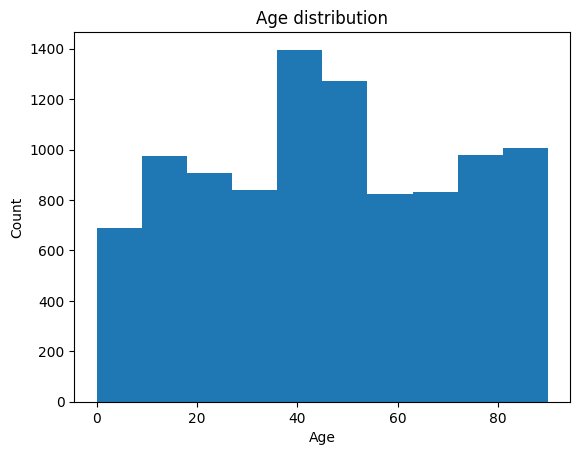

In [ ]:
#Distribution of patient data
plt.hist(data[['age']])
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

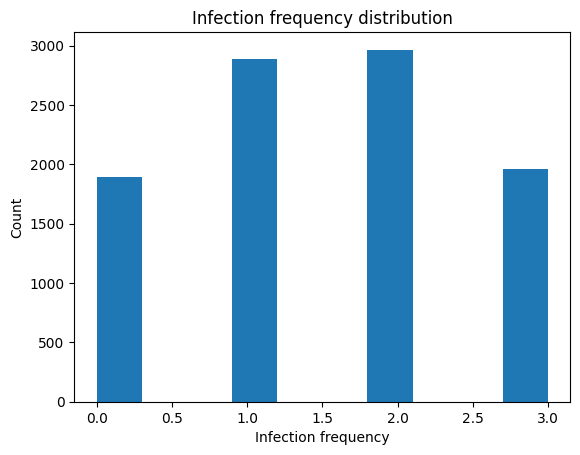

In [ ]:
plt.hist(data['Infection_Freq'])
plt.title('Infection frequency distribution')
plt.xlabel('Infection frequency')
plt.ylabel('Count')

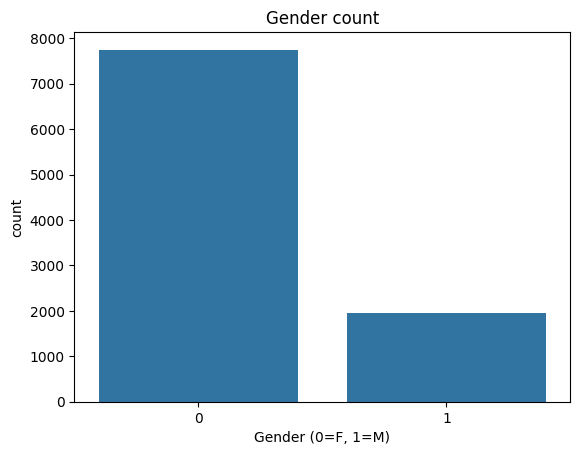

In [ ]:
sns.countplot(x='gender', data=data)
plt.title('Gender count')
plt.xlabel('Gender (0=F, 1=M)')
plt.show()

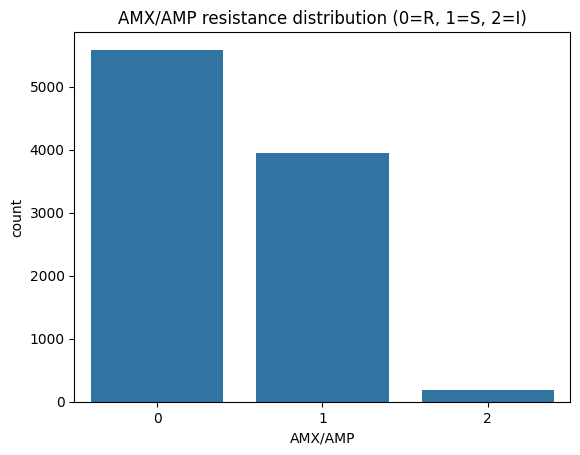

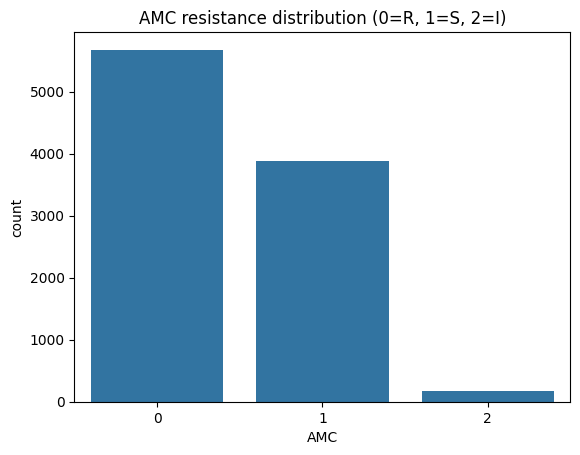

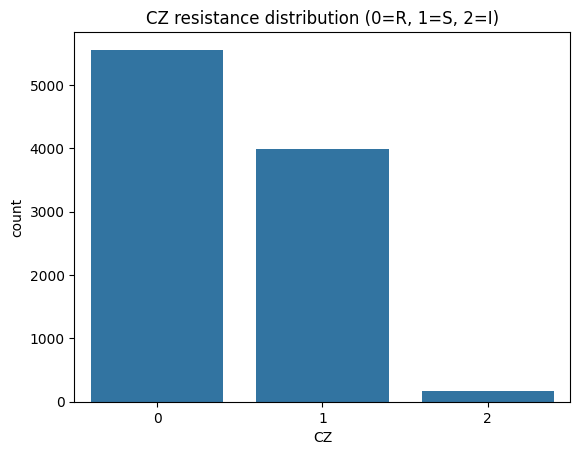

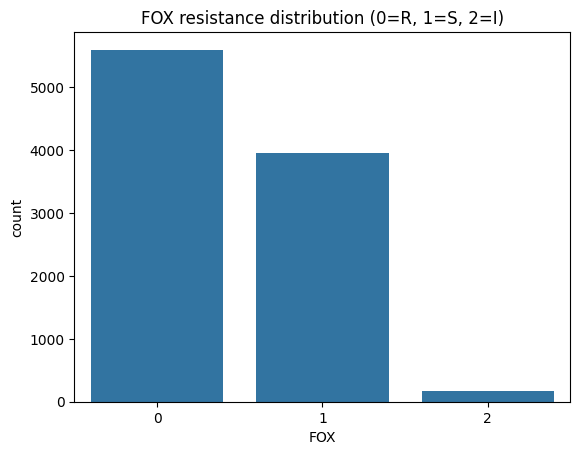

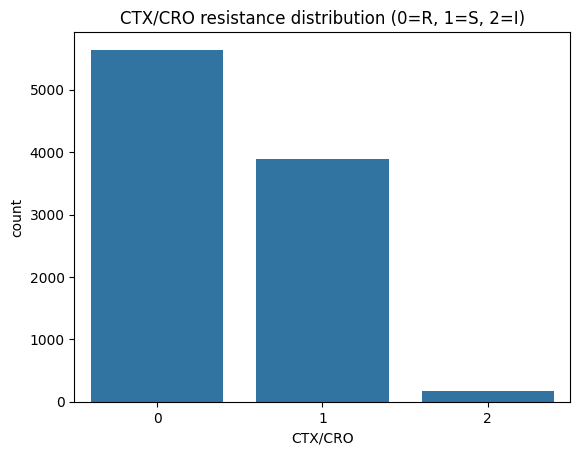

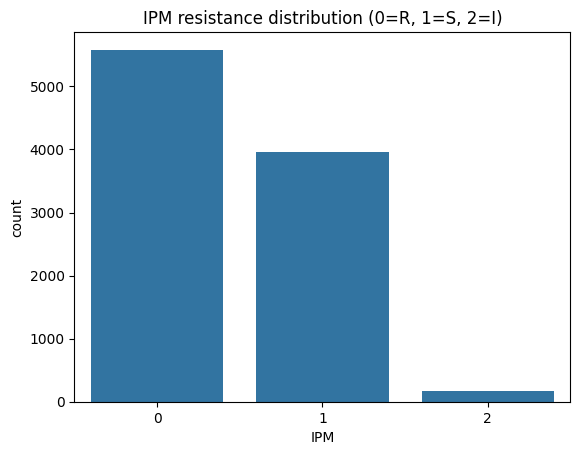

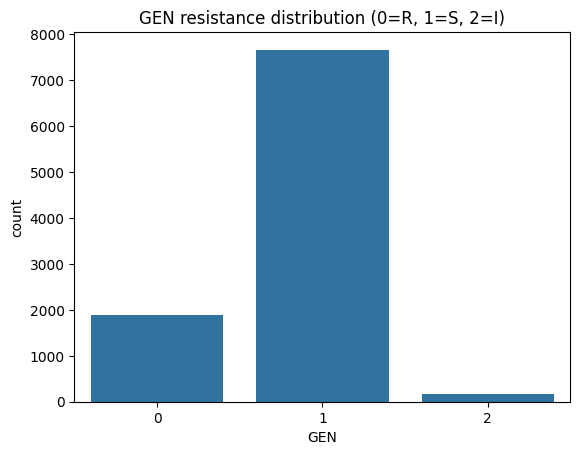

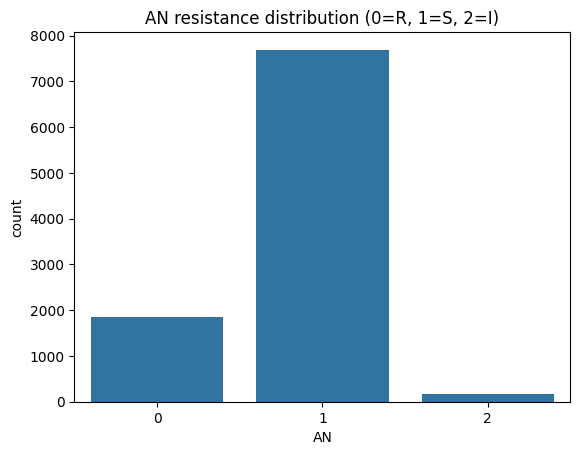

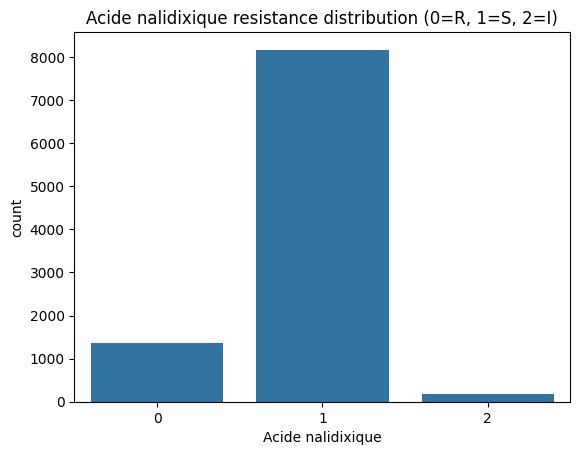

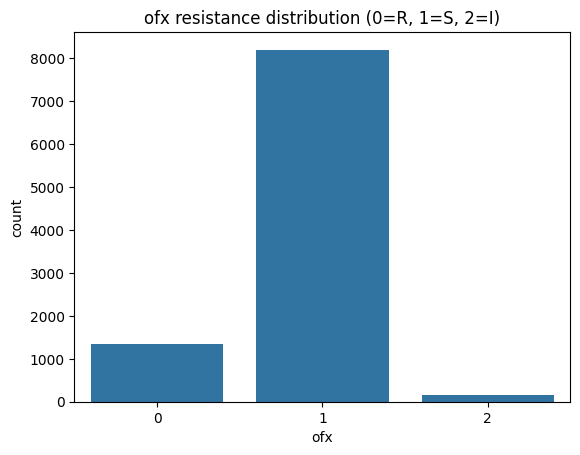

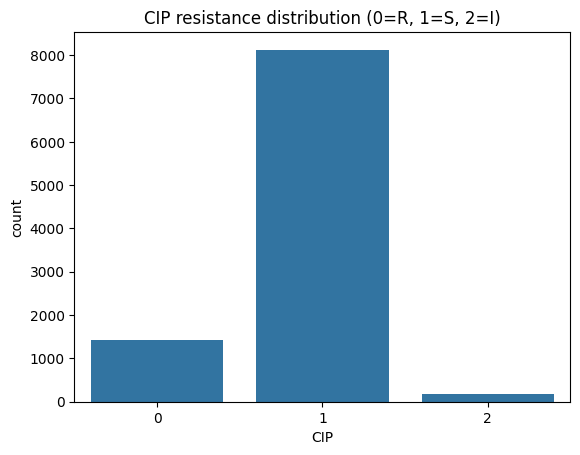

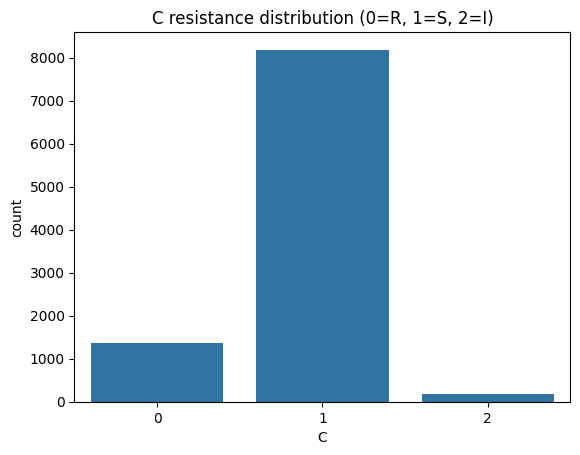

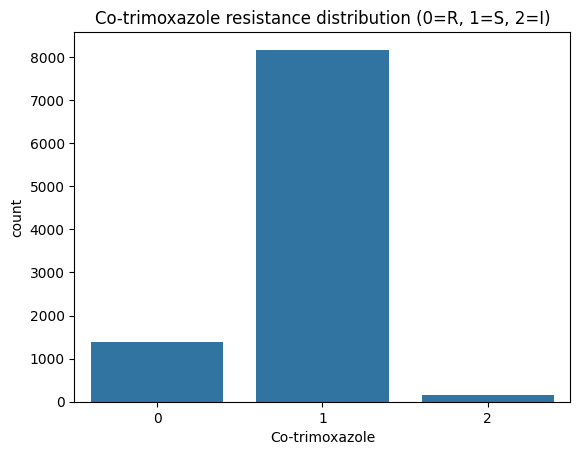

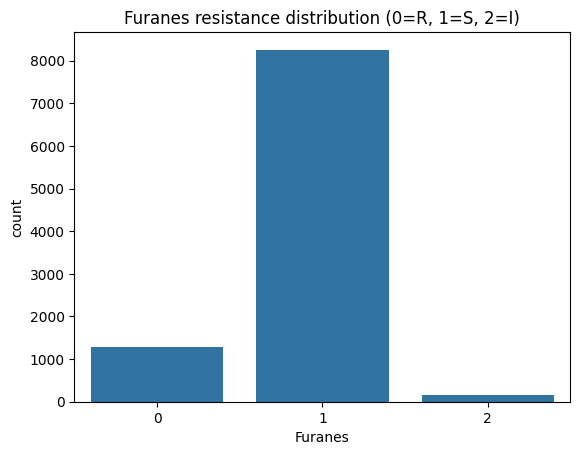

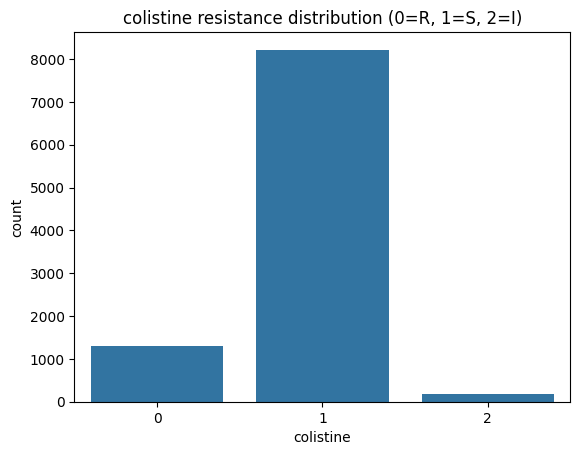

In [ ]:
for antibiotic in antibiotics:
    sns.countplot(x=antibiotic, data=data)
    plt.title(f'{antibiotic} resistance distribution (0=R, 1=S, 2=I)')
    plt.show()

From the graphs above, we can see that values are imbalanced in most cases. That means that we'll have to use weights when working with learning models later.

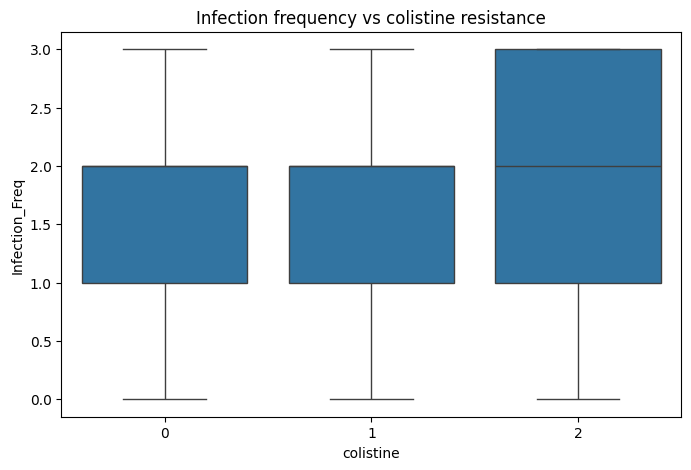

In [ ]:
target_ab = 'colistine'
plt.figure(figsize=(8,5))
sns.boxplot(x=target_ab, y='Infection_Freq', data=data)
plt.title(f'Infection frequency vs {target_ab} resistance')
plt.show()
#plotly boxplot dots

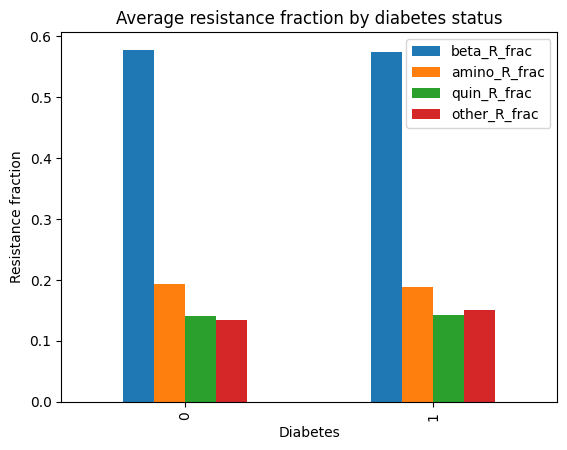

In [ ]:
def resistance_fraction(df, cols):
    return (df[cols] == 0).mean(axis=1)  # 0=R

data['beta_R_frac'] = resistance_fraction(data, beta)
data['amino_R_frac'] = resistance_fraction(data, amino)
data['quin_R_frac'] = resistance_fraction(data, quin)
data['other_R_frac'] = resistance_fraction(data, other)

data.groupby('Diabetes')[['beta_R_frac','amino_R_frac','quin_R_frac','other_R_frac']].mean().plot(kind='bar')
plt.title('Average resistance fraction by diabetes status')
plt.ylabel('Resistance fraction')
plt.show()

# Correlation matrix

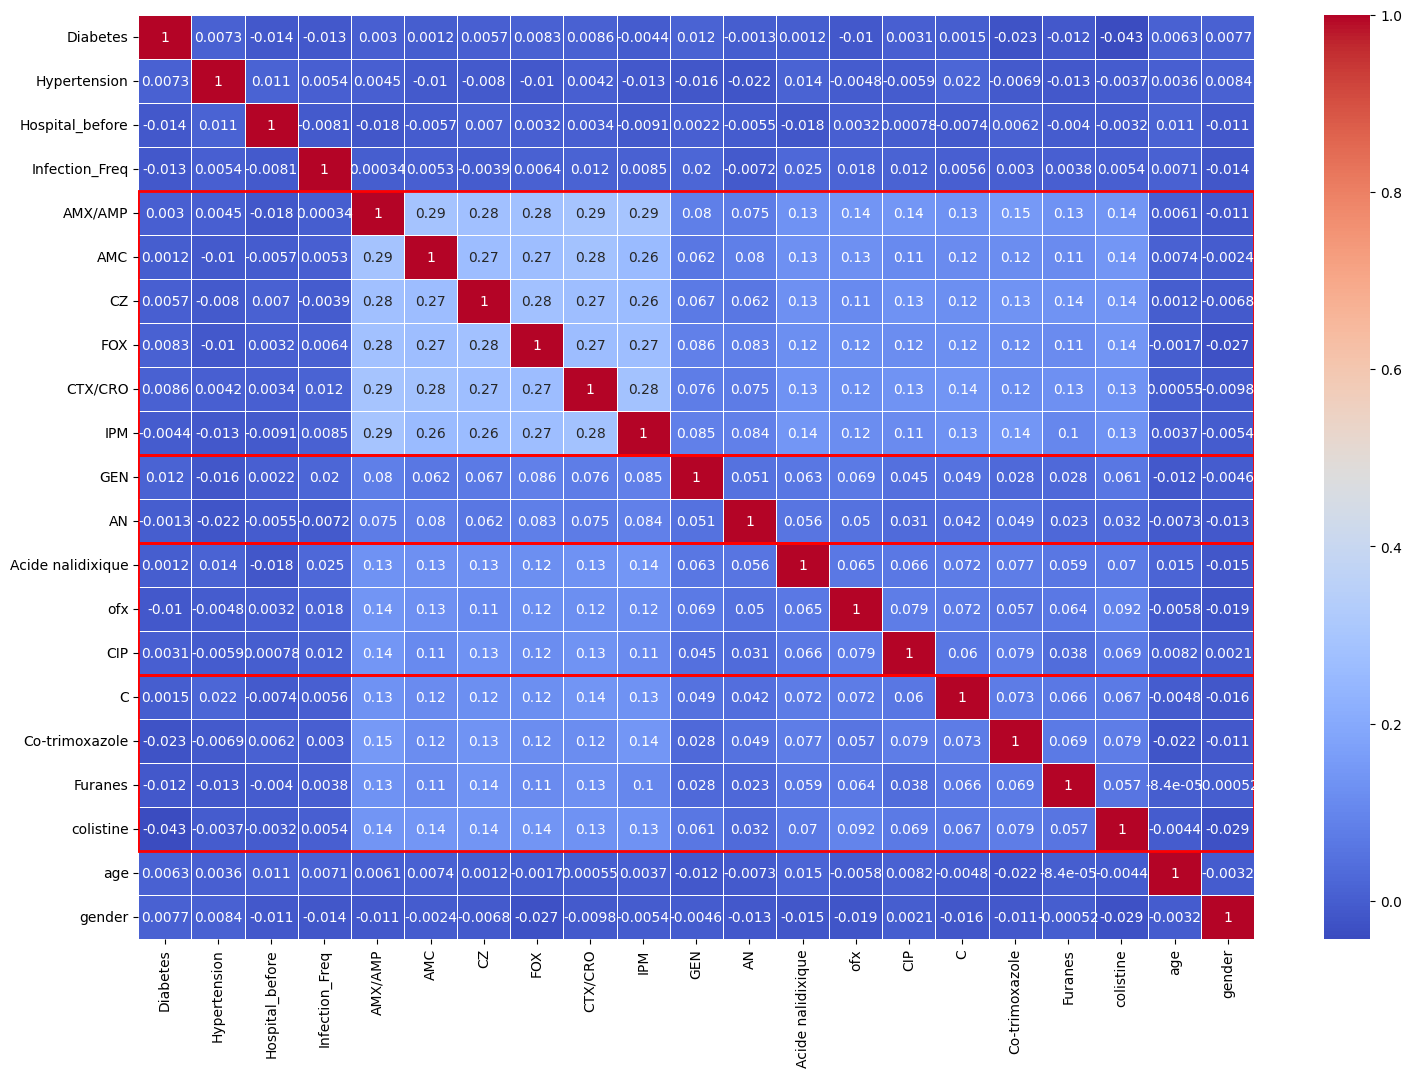

In [ ]:
data = data.drop(['beta_R_frac','amino_R_frac','quin_R_frac','other_R_frac'], axis=1)
plt.figure(figsize=(18,12))
ax = sns.heatmap(data.corr(), annot=True, linewidths=0.5, cmap='coolwarm')
groups = {
    "beta": beta,
    "amino": amino,
    "quin": quin,
    "other": other
}

start = 4
for name, cols in groups.items():
    end = start + len(cols)
    ax.add_patch(plt.Rectangle(
        (0, start),
        data.shape[1], len(cols),
        fill=False,
        edgecolor="red",
        lw=2
    ))

    start = end

plt.show()

From the heatmap we can see that patiant variables are weak predictors. Therefore, the examining relationships between antibiotics will provide stronger predictions. It  is also important to note that the four groups can be clearly seen.

# **Machine Learing**
The goal is to predict the susceptibility to a chosen antibiotic. It is a classification problem, which can be solved using the Desision Tree Model.

Below you can see the comparison between predictions using patients data vs. using the reaction to other antibiotics.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

target = "CIP"
X = data.drop(antibiotics, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

              precision    recall  f1-score   support

           0       0.17      0.38      0.24       283
           1       0.86      0.62      0.72      1625
           2       0.05      0.20      0.08        35

    accuracy                           0.58      1943
   macro avg       0.36      0.40      0.34      1943
weighted avg       0.74      0.58      0.64      1943



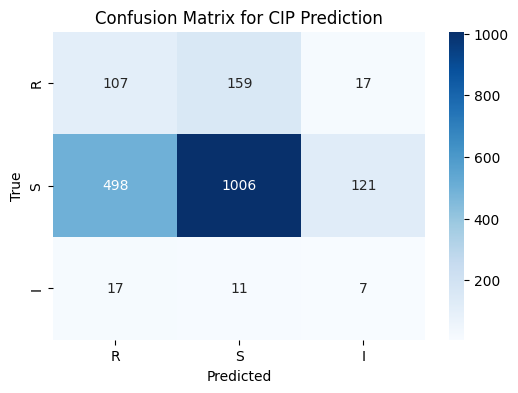

In [ ]:
model = DecisionTreeClassifier(
    criterion="entropy",# measure of impurity
    class_weight="balanced", #we need this because the data is imbalanced (there are way more instances of S)
    random_state=42
)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(classification_report(y_test, pred))


cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["R","S","I"],
            yticklabels=["R","S","I"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for CIP Prediction")
plt.show()

              precision    recall  f1-score   support

           0       0.21      0.51      0.30       283
           1       0.88      0.67      0.76      1625
           2       0.81      0.60      0.69        35

    accuracy                           0.64      1943
   macro avg       0.63      0.59      0.58      1943
weighted avg       0.78      0.64      0.69      1943



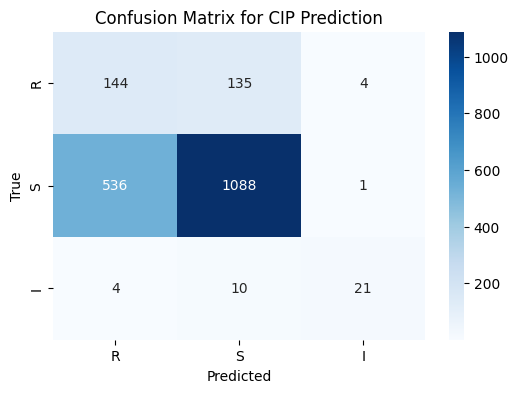

In [ ]:
X = data[antibiotics].drop(target, axis=1)
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = DecisionTreeClassifier(
    criterion="entropy",
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))


cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["R","S","I"],
            yticklabels=["R","S","I"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for CIP Prediction")
plt.show()

              precision    recall  f1-score   support

           0       0.41      0.11      0.17       283
           1       0.86      0.97      0.91      1625
           2       0.76      0.83      0.79        35

    accuracy                           0.84      1943
   macro avg       0.68      0.64      0.63      1943
weighted avg       0.79      0.84      0.80      1943



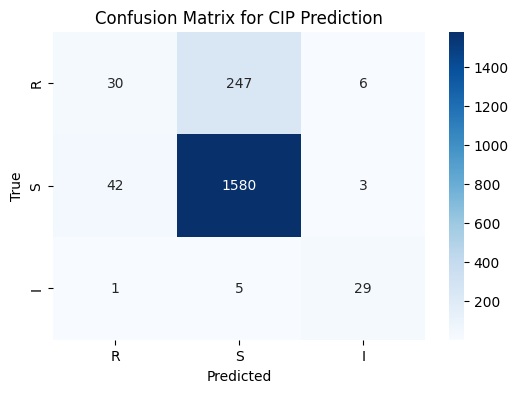

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print(classification_report(y_test, pred))


cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["R","S","I"],
            yticklabels=["R","S","I"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for CIP Prediction")
plt.show()

In [ ]:
feature_importances = rf.feature_importances_
print(feature_importances)

[0.0559765  0.0733059  0.06062439 0.07373236 0.06250635 0.06662339
 0.08210224 0.08166647 0.07743614 0.07637531 0.07557354 0.07327096
 0.06661112 0.07419531]
